In the previous lesson we identified stars with the proper motion we expect for GD-1

Now we'll do the same selection in an ADQL query, which will make it possible to work with a larger region of the sky and still download less data

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import ConvexHull
import astropy.units as u
import GD1Koposov10
from astropy.coordinates import SkyCoord
import reflex_correct

# Reloading the data

Reload the data from the hdf file created in the previous lesson

In [2]:
filename = 'gd1_data.hdf'
centerline_df = pd.read_hdf(filename, 'centerline_df')
selected_df = pd.read_hdf(filename, 'selected_df')

# Selection by proper motion

At this point we have downloaded data for a farily large number of stars (over 100,000) and selected a relatively small number (around 1000)

It would be more efficient to use an ADQL query to select only the stars we need. This method also allows us to download data covering a larger region of the sky 

The selection we did was based on proper motion in the GD-1 frame. In order to do the same selection in ADQL we have to work with proper motion in ICRS 

In [3]:
# The rectangle we selected based on proper motion in the 
# GD-1 frame 
pm1_min = -8.9
pm1_max = -6.9
pm2_min = -2.2
pm2_max =  1.0

In [4]:
def make_rectangle(x1, x2, y1, y2):
    """Return the corners of a rectangle."""
    xs = [x1, x1, x2, x2, x1]
    ys = [y1, y2, y2, y1, y1]
    return xs, ys

In [5]:
pm1_rect, pm2_rect = make_rectangle(
    pm1_min, pm1_max, pm2_min, pm2_max)

In [6]:
def plot_proper_motion(df, marker):
    """Plot proper motion

    df: Dataframe with 'pm_phi1' and 'pm_phi2'
    marker: String to pass in to customise data markers 
    """

    x = df['pm_phi1']
    y = df['pm_phi2']
    plt.plot(x, y, marker, markersize=0.3, alpha=0.3)
    
    plt.xlabel('Proper motion phi1 (GD1 frame)')
    plt.ylabel('Proper motion phi2 (GD1 frame)')

    plt.xlim(-12, 8)
    plt.ylim(-10, 10)

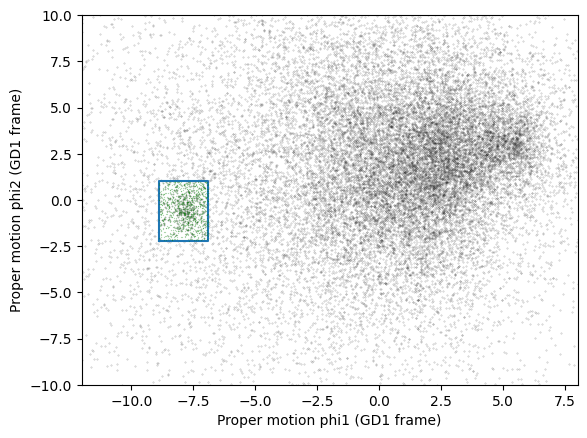

In [7]:
plot_proper_motion(centerline_df, 'ko')

plt.plot(pm1_rect, pm2_rect)

plot_proper_motion(selected_df, 'gx')

The above plot shows:
1) Proper motion for the stars we selected along the centerline of GD-1
2) The rectangle we selected
3) The stars inside the rectangle highlighted in green 

We now need to make the same plot using proper motions in the ICRS frame, which are stored in the columns pmra and pmdec 

(-20.0, 5.0)

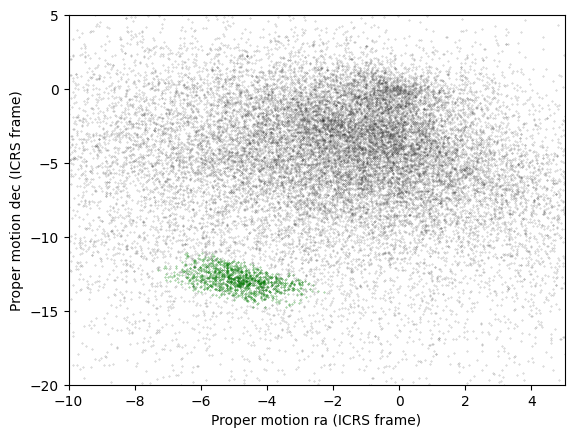

In [8]:
x = centerline_df['pmra']
y = centerline_df['pmdec']
plt.plot(x, y, 'ko',  markersize=0.3, alpha=0.3)

plt.plot(selected_df['pmra'], selected_df['pmdec'], 'gx', markersize=1,
        alpha=0.3)

plt.xlabel('Proper motion ra (ICRS frame)')
plt.ylabel('Proper motion dec (ICRS frame)')


plt.xlim([-10, 5])
plt.ylim([-20, 5])

We can now define a polygon that encloses the proper motions of these stars in ICRS, and use that polygon as a selection criteria in ADQL

# Convex Hull

Scipy provides a function that computes the convex hull of a set of points (The smalles convex polygon that contains all of the points) 

In [9]:
# Converting pmra and pmdec columns into numpy arrays

points = selected_df[['pmra','pmdec']].to_numpy()
points.shape

(1049, 2)

In [10]:
# Pass points to ConvexHull function which returns an
# object that contains the results

hull = ConvexHull(points)
hull

In [11]:
# hull.vertices contains the indicies of the points that fall on the perimeter
# of the hull

hull.vertices

array([ 724, 1039,  682,  855,  842,   84,  626,  579,  897,  909,  179,
        374,  569,  815,  836,  567], dtype=int32)

In [12]:
# We can use the hull verticies as an index into the original
# array to select the corresponding rows

pm_vertices = points[hull.vertices]
pm_vertices

array([[ -4.05037121, -14.75623261],
       [ -3.41981085, -14.72365546],
       [ -3.03521988, -14.44357135],
       [ -2.26847919, -13.7140236 ],
       [ -2.61172203, -13.24797471],
       [ -2.73471401, -13.09054471],
       [ -3.19923146, -12.5942653 ],
       [ -3.34082546, -12.47611926],
       [ -5.67489413, -11.16083338],
       [ -5.95159272, -11.10547884],
       [ -6.42394023, -11.05981295],
       [ -7.09631023, -11.95187806],
       [ -7.30641519, -12.24559977],
       [ -7.04016696, -12.88580702],
       [ -6.00347705, -13.75912098],
       [ -4.42442296, -14.74641176]])

In [13]:
# Pulling out the x and y coordinates
pmra_poly, pmdec_poly = np.transpose(pm_vertices)

We use the numpy transpose function here because pm_verticies has two columns, whereas its matrix transpose has two rows (pmra_poly, and pmdec_poly) 

The following figure shows proper motion in ICRS, along with the convex hull we just computed

(-20.0, 5.0)

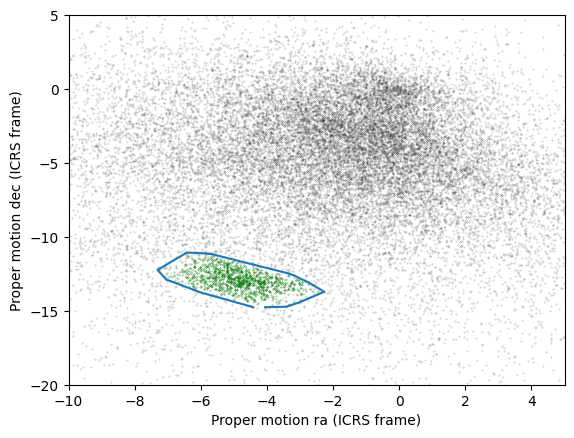

In [14]:
plt.plot(centerline_df['pmra'], centerline_df['pmdec'], 'ko',  
         markersize=0.3, alpha=0.3)

plt.plot(selected_df['pmra'], selected_df['pmdec'], 'gx',
         markersize=1, alpha=0.3)

plt.plot(pmra_poly, pmdec_poly)

plt.xlabel('Proper motion ra (ICRS frame)')
plt.ylabel('Proper motion dec (ICRS frame)')

plt.xlim([-10, 5])
plt.ylim([-20, 5])

# Assembling the ADQL query

We now need to use pm_verticies as part of an ADQL query

Starting with the base query we used in lesson 2 to select stars in a polygonal region

In [15]:
query5_base = """SELECT
{columns}
FROM gaiadr2.gaia_source
WHERE parallax < 1
  AND bp_rp BETWEEN -0.75 AND 2 
  AND 1 = CONTAINS(POINT(ra, dec), 
                   POLYGON({point_list}))
"""

We will make 2 changes:
1) We'll select stars with coordinates in a larger region
2) We'll add another clause to select stars whose proper motion is in the polygon we just computed, pm_verticies 

In [16]:
# Coordinates of the larger rectangle in the GD-1 frame
phi1_min = -70 * u.degree
phi1_max = -20 * u.degree
phi2_min = -5 * u.degree
phi2_max = 5 * u.degree

In [17]:
phi1_rect, phi2_rect = make_rectangle(
    phi1_min, phi1_max, phi2_min, phi2_max)

In [18]:
# Transforming the rectangle into ICRS coordinates

gd1_frame = GD1Koposov10.GD1Koposov10()
corners = SkyCoord(phi1 = phi1_rect,
                   phi2 = phi2_rect,
                   frame = gd1_frame)

corners_icrs = corners.transform_to('icrs')

In [19]:
# Converting corners_icrs into a string so it can be used 
# in an ADQL query 

def skycoord_to_string(skycoord):
    """ Convert SkyCoord to string """
    t = skycoord.to_string()
    s = ' '.join(t)
    return s.replace(' ', ', ')


point_list = skycoord_to_string(corners_icrs)
point_list

'135.306, 8.39862, 126.51, 13.4449, 163.017, 54.2424, 172.933, 46.4726, 135.306, 8.39862'

In [20]:
# Columns that we want to select
columns = "source_id, ra, dec, pmra, pmdec"

# Assembling the query
query5 = query5_base.format(columns = columns,
                            point_list = point_list)
print(query5)

SELECT
source_id, ra, dec, pmra, pmdec
FROM gaiadr2.gaia_source
WHERE parallax < 1
  AND bp_rp BETWEEN -0.75 AND 2 
  AND 1 = CONTAINS(POINT(ra, dec), 
                   POLYGON(135.306, 8.39862, 126.51, 13.4449, 163.017, 54.2424, 172.933, 46.4726, 135.306, 8.39862))



# Selecting proper motion 

Now we're ready to add a WHERE clause to slecet stars whose proper motion falls in the polygon defined by pm_verticies 

We first have to convert pm_verticies into a string, then using flatten and array2string, we can almost get the form we need

In [21]:
s = np.array2string(pm_vertices.flatten(), 
                    max_line_width=1000,
                    separator=',')
s

'[ -4.05037121,-14.75623261, -3.41981085,-14.72365546, -3.03521988,-14.44357135, -2.26847919,-13.7140236 , -2.61172203,-13.24797471, -2.73471401,-13.09054471, -3.19923146,-12.5942653 , -3.34082546,-12.47611926, -5.67489413,-11.16083338, -5.95159272,-11.10547884, -6.42394023,-11.05981295, -7.09631023,-11.95187806, -7.30641519,-12.24559977, -7.04016696,-12.88580702, -6.00347705,-13.75912098, -4.42442296,-14.74641176]'

In [22]:
# Removing the brackets 
pm_point_list = s.strip('[]')
pm_point_list

' -4.05037121,-14.75623261, -3.41981085,-14.72365546, -3.03521988,-14.44357135, -2.26847919,-13.7140236 , -2.61172203,-13.24797471, -2.73471401,-13.09054471, -3.19923146,-12.5942653 , -3.34082546,-12.47611926, -5.67489413,-11.16083338, -5.95159272,-11.10547884, -6.42394023,-11.05981295, -7.09631023,-11.95187806, -7.30641519,-12.24559977, -7.04016696,-12.88580702, -6.00347705,-13.75912098, -4.42442296,-14.74641176'

# Excercise
Define query6_base, starting with query5_base and adding a new clause to select stars whose coordinates of proper motion fall within the polygon defined by pm_point list

In [23]:
query6_base = """SELECT 
{columns}
FROM gaiadr2.gaia_source
WHERE parallax < 1
  AND bp_rp BETWEEN -0.75 AND 2 
  AND 1 = CONTAINS(POINT('ICRS', ra, dec), 
                   POLYGON({point_list}))
  AND 1 = CONTAINS(POINT('ICRS', pmra, pmdec),
                   POLYGON({pm_point_list}))
"""

In [24]:
query6 = query6_base.format(columns=columns, 
                            point_list=point_list,
                            pm_point_list=pm_point_list)
print(query6)

SELECT 
source_id, ra, dec, pmra, pmdec
FROM gaiadr2.gaia_source
WHERE parallax < 1
  AND bp_rp BETWEEN -0.75 AND 2 
  AND 1 = CONTAINS(POINT('ICRS', ra, dec), 
                   POLYGON(135.306, 8.39862, 126.51, 13.4449, 163.017, 54.2424, 172.933, 46.4726, 135.306, 8.39862))
  AND 1 = CONTAINS(POINT('ICRS', pmra, pmdec),
                   POLYGON( -4.05037121,-14.75623261, -3.41981085,-14.72365546, -3.03521988,-14.44357135, -2.26847919,-13.7140236 , -2.61172203,-13.24797471, -2.73471401,-13.09054471, -3.19923146,-12.5942653 , -3.34082546,-12.47611926, -5.67489413,-11.16083338, -5.95159272,-11.10547884, -6.42394023,-11.05981295, -7.09631023,-11.95187806, -7.30641519,-12.24559977, -7.04016696,-12.88580702, -6.00347705,-13.75912098, -4.42442296,-14.74641176))



In [25]:
from astroquery.gaia import Gaia

job = Gaia.launch_job_async(query6)
print(job)

Some IP addresses of users launching heavy query showers have temporarily been disabled. Please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk) for advice. Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive
500 Error 500:
Cannot invoke "java.util.List.iterator()" because "results" is null


HTTPError: Error 500:
Cannot invoke "java.util.List.iterator()" because "results" is null